# 非線形バネモデルへの入力制限を行うC/GMRESの適用

[非線形バネモデルへのC/GMRES](nonlinear_spring.ipynb)では通常の状態方程式の制約のみであった。

このNoteでは制御入力 $|u| \le u_{max}$ の制約を行うC/GMRESの適用を実施する。

## モデリング

非線形バネモデルは[通常のC/GMRES](nonlinear_spring.ipynb)で用いた1質点モデルとする。

<img src="images/one-degree-nonlinear-spring.png" style="width:40%;">

状態$X(t)$を以下のようにすると、

$$
X(t) = [x(t), v(t)]^T
$$

状態方程式 $\dot{X} = f(X, u)$ は次のようになる。

$$
\frac{d}{dt}\begin{bmatrix}
x(t) \\ v(t)
\end{bmatrix} =
\begin{bmatrix}
v(t) \\ \dfrac{1}{m}\left(u(t) - k x(t) - k_3 x(t)^3 \right)
\end{bmatrix}
$$

### 評価関数とコスト

制御入力 $u$ の制約はダミー入力 $u_d$ を用いて次の等式制約$C(u, u_d)$となる。

$$
C(u, u_d) = u(t)^2 + u_d(t)^2 - u^2_{max} = 0
$$

$C$を用いて拡大評価関数$\bar{J}$は次のように構成される。

$$
\bar{J} = \Phi(X(T)) + \int_0^T \left[ L_d(X, u, u_d) + \lambda^T \left(f(X, u) - \dot{X} \right) + \rho C(u, u_d) \right] dt
$$

#### ランニングコスト $L_d$

ランニングコスト $L_d(X, u, u_d)$は次のように設定する。入力制限のため $r_d u_d, r_d > 0$ の項目を設定している。これにより、ダミー変数だけでは$u_d$の解が2つ生じるが、正側の$u_d>0$を選択できるようになる。詳しくは[不等式制約のダミー変数による等式化の節](../Notes/Inequality_constraint.ipynb)を参照。

$$
L_d(X, u, u_d) = \frac{1}{2}q_x(x(t) - x_{ref})^2 + \frac{1}{2}q_v v(t)^2 + \frac{1}{2} r u(t)^2 - r_d u_d
$$

$\bar{J}$の最小化問題であるため、ゲイン $q_x, q_v, r$に関する項は次の意味となる。

- $q_x$ : 位置の目標値と誤差を小さくする
- $q_v$ : 速度を大きくしない
- $r$ : 入力を大きくしない

また、 $-r_d u_d$の設定により、$r_d >0$ となるように選択する。

#### 終端コスト $\Phi$

終端コスト $\Phi(X(T))$ は次のように設定する。

$$
\Phi(X(T)) = \frac{1}{2}q_{xT}(x(T) - x_{ref})^2 + \frac{1}{2} q_{vT} v(T)^2
$$

$\bar{J}$の最小化問題であるため、ゲイン $q_{xT}, q_{vT}$に関する項は次の意味となる。

- $q_{xT}$ : 時刻$T$における位置の目標値と誤差を小さくする
- $q_{vT}$ : 時刻$T$における速度を大きくしない

#### 随伴変数　$\lambda$

$\lambda$は状態方程式制約$f(X,u) - \dot{X}$ と内積をとり、$\lambda^T (f(X,u) - \dot{X}) $がスカラーとなるように設定する。状態$X$は2変数であるため、$\lambda$を次のように設定する。

$$
\lambda = [\lambda_x, \lambda_v]^T
$$

#### 等式制約の係数 $\rho$

$C(u, u_d)$がスカラーであるため、$\rho$もスカラーである。


### PMP 条件

Hamiltonin $H$ は次の式である。

$$
H(X, u, u_d, \lambda, \rho) = L_d (X, u, u_d) + \lambda^T f(X,u) + \rho C(u, u_d)
$$

$$
H = \frac{1}{2} q_x(x(t) - x_{ref})^2 + \frac{1}{2} q_v v(t)^2 + \frac{1}{2} r u(t)^2 - r_d u_d + \lambda_x v(t) + \frac{\lambda_v}{m}\left(u(t) - k x(t) - k_3 x(t)^3  \right) + \rho (u^2(t) + u_d^2(t) - u^2_{max})
$$

PMP条件を構成するため、$H$ を$X,u, u_d, \lambda, \rho$で偏微分、$\Phi$を$X(T)$ で偏微分を行う。また、$H_\lambda = f(X,u)$ である。

$$
\begin{aligned}
H_X &= \frac{\partial H}{\partial X} = \begin{bmatrix} \partial H / \partial x \\ \partial H / \partial v \end{bmatrix} =
\begin{bmatrix}
q_x(x(t) - x_{ref}) - \lambda_v/m \ \left( k + 3 k_3 x(t)^2 \right) \\
q_v v(t) + \lambda_x 
\end{bmatrix} \\
H_u &= \frac{\partial H}{\partial u} = r u(t) + \frac{\lambda_v}{m} + 2\rho u(t)\\
H_{u_d} &= \frac{\partial H}{\partial u_d} = -r_d + 2\rho u_d(t)\\
H_\rho &= \frac{\partial H}{\partial \rho} = u^2(t) + u_d^2(t) - u^2_{max}\\
\Phi_X &= \frac{\partial \Phi}{\partial X} = \begin{bmatrix} \partial \Phi / \partial x \\ \partial \Phi / \partial v \end{bmatrix} =
\begin{bmatrix}
q_{xT}(x(T) - x_{ref}) \\
q_{vT} v(T)
\end{bmatrix} 
\end{aligned}
$$


$H$を用いて、PMP条件は次のようになる。

$$
\begin{array}{l}
\dot{X} = H_\lambda \\
\lambda(T) = \Phi_X(X(T)) \\
\dot{\lambda} = - H_X \\
H_u = 0 \\
H_{u_d} = 0 \\
H_\rho = 0
\end{array}
$$ 

よって1質点の非線形バネモデルにおけるPMP条件の式は以下となる。

状態方程式

$$
\boxed{
\frac{d}{dt}
\begin{bmatrix}
x(t) \\ v(t)
\end{bmatrix}
= \begin{bmatrix}
v(t) \\ \dfrac{1}{m}\left( u(t) - k x(t) - k_3 x(t)^3 \right)
\end{bmatrix}
}
$$

終端条件

$$
\boxed{
\begin{bmatrix}
\lambda_x(T) \\ \lambda_v(T)
\end{bmatrix} =
\begin{bmatrix}
q_{xT}(x(T) - x_{ref}) \\
q_{vT} v(T)
\end{bmatrix} 
}
$$

随伴方程式

$$
\boxed{
\frac{d}{dt}
\begin{bmatrix}
\lambda_x \\ \lambda_v
\end{bmatrix}
=-\begin{bmatrix}
q_x(x(t) - x_{ref}) - \lambda_v/m \ \left( k + 3 k_3 x(t)^2 \right) \\
q_v v(t) + \lambda_x 
\end{bmatrix}
}
$$

停留条件

$$
\boxed{
F=
\begin{bmatrix}
r u(t) + \frac{\lambda_v}{m}  + 2\rho u(t) \\
-r_d + 2\rho u_d(t)  \\
u(t)^2 + u_d(t)^2 - u^2_{max} 
\end{bmatrix} = 0
}
$$


#### ダミー変数と$r_d u_d$の項の効果

等式制約 $C(u, u_d) = u^2 + u_d^2 - u_{max}^2 = 0$ であるため、

$$
u^2 + u_d^2 = u_{max}^2
$$

となり、これは、中心(0,0)で半径$u_{max}$の円であり、$(u, u_d)$ は円周上の点であるといえる。$X$軸を$u$、$Y$軸に$u_d$とすると、$u$が$u_{max}$に近づくほど$u_d$は小さくなっていく。

ここで $u$に関する停留条件 $H_u$、$u_d$に関する停留条件 $H_{u_d}$は以下である。

$$
\begin{aligned}
H_u = r u + \frac{\lambda_v}{m}  + 2\rho u = 0\\
H_{u_d} = -r_d + 2\rho u_d = 0  \rightarrow \rho = \frac{r_d}{2 u_d}\\
\end{aligned}
$$

$H_u$に$\rho$を代入すると、以下の関係式になる。

$$
H_u = r u + \frac{\lambda_v}{m}  + \frac{r_d}{u_d} u = 0
$$

$u$が$u_{max}$に近くなるつれ、$u_d$が小さくなっていく。すると、$H_u$の $\dfrac{r_d}{u_d} u$が大きくなる結果、$u$を$u_{max}$へ近づくことを抑制するといったことが行われる。


#### 制約 $C$ のスケーリング

$C$の制約を見ると、以下のように半径$u_max$の円である。

$$
u^2 + u_d^2 = u^2_max
$$

例えば、$u_max = 10$とした場合、例えば$u=0, u_d=9$ なら 制約の残差は$C=-19$となる。

$$
C=u^2 + u_d^2 - u_max^2 = 81 - 100 = -19
$$

C/GMRESで解いている残差は

$$
F=[H_u, H_{u_d}, C]^T
$$

であり、例えば $H_u \backsim 0.1, H_{u_d} \backsim 0.01, C \backsim 10$のようになると、

$$
F=[0.1, 0.01, 10]^T
$$

のようになり、3種類の式のスケーリングが全く異なることが生じる。

これを

$$
\bar{C} = \frac{C}{u_{max}}
$$

とすれば、以下のように半径1の単位円となり、

$$
\frac{u^2}{u^2_{max}} + \frac{u_d^2}{u} = 1
$$

$u_{max} = 10, u=0, u_d = 9$と置いても$\bar{C}$の残差は$-0.19$となり、数値のスケーリングができ、計算で解く際に有利になる。

$$
\bar{C} = \frac{0}{100} + \frac{81}{100} - 1.0 = -0.19
$$

$C \rightarrow \bar{C}$ と変更したため、$H$は次のように変更される。

$$
H = L_d + \lambda^T f + \rho \bar{C}(u, u_d)
$$

よって影響は$u, u_d, \rho$で偏微分する以下の式になる。

$$
\begin{aligned}
H_u &= r u(t) + \frac{\lambda_v}{m} + \frac{2 \rho u(t)}{u^2_{max}} \\
H_{u_d} &= -r_d + \frac{2 \rho u(t)}{u^2_{max}} \\
H_\rho &= \bar{C} = \frac{u^2(t) + u_d^2(t)}{u^2_{max}} - 1
\end{aligned}
$$

これより、停留条件の式が以下のようになる。

$$
\boxed{
F=
\begin{bmatrix}
r u(t) + \frac{\lambda_v}{m}  + \frac{2 \rho u(t)}{u^2_{max}} \\
-r_d + \frac{2 \rho u(t)}{u^2_{max}}  \\
\frac{u^2(t) + u_d^2(t)}{u^2_{max}} - 1
\end{bmatrix} = 0
}
$$



#### 求めるべき $U$ の構成

C/GMRESでは予測ホライゾン上の各時刻$\tau$で、上記の式を満たす必要がある。上式では、$u(\tau),u_d(\tau), \rho(\tau)$が未定の値である。よって、$U(t_k)$ を次のように設定する。

$$
U(t_k) = [u_0(t_k), u_{d_0}(t_k) , \rho_0(t_k) , \cdots , u_{N-1}(t_k), u_{d_{N-1}}(t_k) , \rho_{N-1}(t_k)]^T
$$

### 状態 $X$ 随伴変数 $\lambda$ の時系列の計算式と停留条件式 $F$ の構成

入力列 $U(t_k)$ 、状態の初期値 $X[0]$、予測ホライゾンの長さ$T(t_k)=T_f(1 - \exp(-\alpha t_k))$ の$t_k$を設定値として時系列を計算する。

予測ホライゾンのステップ幅 $h(t_k)$ は $T(t_k)$の分割数 $N$ より以下のようになる。

$$
h(t_k) = T(t_k) / N
$$

以下の式は上から順に、状態$X[n]$、終端状態 $\lambda[N]$、随伴変数 $\lambda[n]$ に関する。

$$
\begin{aligned}
\begin{bmatrix}
x[n+1] \\ v[n+1]
\end{bmatrix} &=
\begin{bmatrix}
x[n] \\ v[n]
\end{bmatrix} +
h\begin{bmatrix}
v[n] \\ \dfrac{1}{m}\left( u_n(t_k) - k x[n] - k_3 x[n]^3 \right)
\end{bmatrix}, \quad n = 0, \cdots , N-1 \\
\begin{bmatrix}
\lambda_x[N] \\ \lambda_v[N]
\end{bmatrix} &=
\begin{bmatrix}
q_{xT}(x[N] - x_{ref}) \\
q_{vT} v[N]
\end{bmatrix} \\
\begin{bmatrix}
\lambda_x[n] \\ \lambda_v[n]
\end{bmatrix} &=\begin{bmatrix}
\lambda_x[n+1] \\ \lambda_v[n+1]
\end{bmatrix}
+h\begin{bmatrix}
q_x(x[n] - x_{ref}) - \lambda_v[n+1]/m \ \left( k + 3 k_3 x[n]^2 \right) \\
q_v v[n] + \lambda_x[n+1] 
\end{bmatrix} , \quad n = N-1, \cdots , 1
\end{aligned}
$$

上記を用いて、停留条件式 $F(X(t_k), U(t_k))$ を以下のように構成する。

$$
F(X(t_k), U(t_k)) = 
\begin{bmatrix}
r u_0(t_k) + \dfrac{\lambda_v[1]}{m} + \dfrac{2\rho_0(t_k) u_0(t_k)}{u^2_{max}}\\
-r_d + \dfrac{2\rho_0(t_k) u_{d_0}(t_k)}{u^2_{max}}  \\
\dfrac{u_0(t_k)^2 + u_{d_0}(t_k)^2}{u^2_{max}} - 1 \\
\vdots \\
r u_{N-1}(t_k) + \dfrac{\lambda_v[N]}{m} + \dfrac{2\rho_{N-1}(t_k) u_{N-1}(t_k)}{u^2_{max}}\\
-r_d + \dfrac{2\rho_{N-1}(t_k) u_{d_{N-1}}(t_k)}{u^2_{max}}  \\
\dfrac{u_{N-1}(t_k)^2 + u_{d_{N-1}}(t_k)^2}{u^2_{max}} - 1 \\
\end{bmatrix} = 0
$$

また、この時系列から$F$を構成する計算はC/GMRESの実行中に何度も行われる。そのため

$$
F(U(t_k), X(t_k), t_k)
$$

を関数として定義する。これは、$U(t_k)$ に制御入力列、$X(t_k)$ に実時間 $t_k$ における現在状態を与え、それを予測区間の初期状態$X[0]$として使用する、$t_k$を$T(t_k)$ を計算する入力として与えれれば、それをもとに停留条件の式 $F(U(t_k), X(t_k), t_k)$ を構成する、という意味である。

#### 初期 $U(0)$ の計算

求めるべき変数が $u(0), u_d(0), \rho(0)$ と3つであるため、Newton-Raphson法により求める。

以下の$F(U)$を $U = [u, u_d, \rho]$ で偏微分してヤコビアン$J_F$を求める。

$$
F(U)= \begin{bmatrix}
H_u \\ H_{u_d} \\ C 
\end{bmatrix} = 
\begin{bmatrix}
r u(t) + \frac{\lambda_v}{m}  + \frac{2 \rho u(t)}{u^2_{max}} \\
-r_d + \frac{2 \rho u(t)}{u^2_{max}}  \\
\frac{u^2(t) + u_d^2(t)}{u^2_{max}} - 1
\end{bmatrix}
$$

$$
J_F(U) = \frac{\partial F}{\partial U} =
\begin{bmatrix}
\dfrac{\partial H_u}{\partial u} & \dfrac{\partial H_u}{\partial u_d} & \dfrac{\partial H_u}{\partial \rho} \\ 
\dfrac{\partial H_{u_d}}{\partial u} & \dfrac{\partial H_{u_d}}{\partial u_d} & \dfrac{\partial H_{u_d}}{\partial \rho} \\ 
\dfrac{\partial C}{\partial u} & \dfrac{\partial C}{\partial u_d} & \dfrac{\partial C}{\partial \rho} \\ 
\end{bmatrix} =
\begin{bmatrix}
r + 2 \rho/u^2_{max} & 0 & 2 u(t)/u^2_{max} \\
0 & 2 \rho/u^2_{max} & 2 u_d(t)/u^2_{max} \\
2 u(t)/u^2_{max} & 2 u_d(t)/u^2_{max} & 0
\end{bmatrix}
$$


初期 $U^{(0)}=[u^{(0)}, u_d^{(0)}, \rho^{(0)}] $ を決め、$F(U),J_F(U)$を用いて、以下の式をLU分解で解き、$\Delta U$ を求る。

$$
J_F(U^{(j)}) \Delta U = -F(U^{(j)})
$$

次に以下のように$U^{(j+1)}$ を更新する。

$$
U^{(j+1)} = U^{(j)} + \Delta U
$$

そして、$||F(U^{(j+1)})||$が以下のように十分小さくなるまで上記を繰り返す。

$$
||F(U^{j+1})|| < \sigma
$$

ループが停止したときの$U^{(j+1)} = [u^{(j+1)}, u_d^{(j+1)}, \rho^{(j+1)}]$を$U(0)$の要素$[u(0), u_d(0), \rho(0)]$と決定し、以下のように$U(0)$を予測ホライゾンの区間の離散時間に対応させた形で構成する。

$$
U(0) = [u(0), u_d(0), \rho(0), \cdots , u(0), u_d(0), \rho(0)]^T \in \mathbb{R}^{3N}
$$

$F(U)$ の計算で用いる $\lambda_v$ は、 $U(0) = 0$ であるため、以下のように状態 $X(0)$ を用いて計算を行う。

$$
\lambda(0) = \Phi_X(X(0)) \rightarrow \lambda_v = q_{vT} v(0)
$$



以上がC/GMRESを計算するために必要設定である。

これらの計算を用いてC/GMRESの制御ループを以下のように実行する。

## C/GMRESの計算

### Step 1 状態取得

制御対象の状態 $X(t_k)$ を取得する。

### Step 2 制御入力列の更新

入力列 $U(t_k) \ \in \mathbb{R}^{3N}$ は前回のC/GMRESで計算された値を用いる。

$t_0$ の場合、上記のNewton-Raphson法で $X(0)$から$u(0), u_d(0), \rho(0)$ を計算し、$U(t_0) \ \in \mathbb{R}^{3N}$ の入力列を構成する。

$$
U(t_0) = [u(0), u_d(0), \rho(0), \cdots , u(0), u_d(0), \rho(0)]^T
$$

### Step 3 制御対象へ制御入力を出力

制御対象へ 制御入力列 $U(t_k)$ の第一要素 $u_0(t_k)$を出力する。

### Step 4 状態$\dot{X}$の計算

$\dot{X}(t_k) = f(X(t_k), u_0(t_k))$ を計算する。

今回の場合、以下の状態方程式を計算する。

$$
\frac{d}{dt}
\begin{bmatrix}
x(t_k) \\ v(t_k)
\end{bmatrix}
= \begin{bmatrix}
v(t_k) \\ \dfrac{1}{m}\left( u_0(t_k) - k x(t_k) - k_3 x(t_k)^3 \right)
\end{bmatrix}
$$

### Step 5 停留条件の計算

$F(U(t_k), X(t_k), t_k)$ を計算する。

### Step 6 右辺 $b_k$ の計算

GMRESの右辺に渡す $b_k$ を計算する。

$F(U(t_k) , X(t_k) + \varepsilon \dot{X}(t_k) , t_k + \varepsilon)$ を計算する。

$$
b_k = - \frac{F(U(t_k) , X(t_k) + \varepsilon \dot{X}(t_k) , t_k + \varepsilon) - F(U(t_k), X(t_k), t_k)}{\varepsilon} - \zeta F(U(t_k), X(t_k), t_k)
$$

### Step 7 GMRESの計算

#### Step 7-1 初期残差の計算

初期残差 $r_0$ の計算に用いる初期解を $\dot{U}^{(0)}(t_k)$を前回の制御ループで計算した $\dot{U}(t_{k-1})$ とする。

$t_0$ の場合、$\dot{U}^{(0)}(t_0)=0$ とする。

$t_k$ の場合、$r_0$ を計算する $F_U \dot{U}^{(0)}(t_k)$ を以下で計算する。

$$
F_U \dot{U}^{(0)}(t_k) = \frac{F(U(t_k) + \varepsilon \dot{U}^{(0)}(t_{k}), X(t_k), t_k) - F(U(t_k), X(t_k), t_k)}{ \varepsilon}
$$

以上より、初期残差を計算する。

$$
r_0 = b_k - F_U \dot{U}^{(0)}(t_k)
$$

#### Step 7-2 直交基底 $v_1$ の計算

$$
v_1 = r_ 0 / \beta , \quad \beta = ||r_0||
$$

#### Step 7-3 Arnoldi法 Step m (m=$1, \cdots $)

$$
\begin{aligned}
F_U(t_k) v_m &= \frac{F(U(t_k) + \varepsilon v_m, X(t_k), t_k) - F(U(t_k), X(t_k), t_k)}{\varepsilon} \\
h_{i, m} &= v_i^T F_U(t_k) v_m \quad (i = 1, \cdots , m) \\
w &= F_U(t_k) v_m - \sum_{i=1}^{m} h_{i,m} v_i \\
h_{m+1, m} &= ||w|| \\
v_{m+1} &= w / h_{m+1, m}
\end{aligned}
$$

この後、これまでのGivens回転を今回構成される 上ヘッセンベルグ行列の列へ適用し、上三角行列を作る。

残差 $g$ が目標よりも小さければ 最小二乗問題を解き、$Y_m$ を計算し、Arnoldi法の繰り返しを終了する。
そうでなければ、Arnoldi法のStep を繰り返す。

#### Step 7-4 $\dot{U}(t_k)$ の近似解を計算

Arnoldi法が停止した Step m では Krylov部分空間の直交基底 $V_m$ と、$Y_m$ が求まっている。
これを用いて、$\dot{U}(t_k)$ を次のように構成する。

$$
\dot{U}(t_k) = \dot{U}^{(0)}(t_k) + V_m Y_m
$$

### Step 8 次の制御入力列 $U(t_{k+1})$ を計算

求めた $\dot{U}(t_k)$ から、次の時刻の $U(t_{k+1})$ を以下の方法で計算する。

$$
U(t_{k+1}) = U(t_k) + \Delta t \  \dot{U}(t_k) , \quad \Delta t = t_{k+1} - t_{k}
$$


# 実装

Pythonによるダミー変数による制約付きC/GMRESの実装を行う

pythonのnumbaによる計算処理高速化を行う

In [2]:
from dataclasses import dataclass
import numpy as np
from scipy.linalg import lu_factor, lu_solve
from numba import njit

@njit(cache=True)
def _state_equation_numba(x,v,u,m,k,k3):
    dx = v
    dv = (u - k*x - k3* x**3) / m
    return dx, dv

@njit(cache=True)
def _calc_F_numba(U, X0, t, N, Tf, Ta, m, k, k3, qx, qv, qxt, qvt, x_target, r, r_d, u_max):
    # 予測ホライゾンの長さを計算
    T = Tf * (1.0 - np.exp(-Ta * t))
    # ステップ幅を計算
    h = T / N

    # 状態の時系列設定
    Xs = np.zeros((N + 1, 2))
    # 随伴変数の時系列設定
    Ls = np.zeros((N + 1, 2))

    # 状態の初期値を設定
    Xs[0, 0] = X0[0]
    Xs[0, 1] = X0[1]

    # 状態方程式を用いて状態の時系列を計算
    for i in range(N):
        u_i = U[i * 3]
        dx, dv = _state_equation_numba(Xs[i, 0], Xs[i, 1], u_i, m, k, k3)
        Xs[i + 1, 0] = Xs[i, 0] + h * dx
        Xs[i + 1, 1] = Xs[i, 1] + h * dv

    # 終端条件から時刻 N 時の随伴変数を計算
    Ls[N, 0] = qxt * (Xs[N, 0] - x_target)
    Ls[N, 1] = qvt * Xs[N, 1]

    # 随伴方程式を用いて随伴変数の時系列を後退する方向へ計算
    for i in range(N - 1, -1, -1):
        dLx = -qx * (Xs[i, 0] - x_target) + Ls[i + 1, 1] / m * (k + 3.0 * k3 * Xs[i, 0] ** 2)
        dLv = -qv * Xs[i, 1] - Ls[i + 1, 0]
        Ls[i, 0] = Ls[i + 1, 0] - h * dLx
        Ls[i, 1] = Ls[i + 1, 1] - h * dLv

    # 停留条件式の構成
    F = np.zeros(N * 3)
    for i in range(N):
        idx_u = i * 3 + 0
        idx_ud = i * 3 + 1
        idx_r = i * 3 + 2
        u_val = U[idx_u]
        ud_val = U[idx_ud]
        r_val = U[idx_r]
        F[idx_u] = r * u_val + Ls[i + 1, 1] / m + 2.0 * r_val * u_val / u_max**2
        F[idx_ud] = -r_d + 2.0 * r_val * ud_val / u_max**2
        F[idx_r] = (u_val**2 + ud_val**2) / u_max**2 - 1.0

    return F


@dataclass
class Parameters:    
    # 非線形バネモデル
    m: float = 1.0  # 質量
    k: float = 1.0  # バネ定数
    k3: float = 2.0  # 3次のバネ定数
    
    # 目標位置
    x_target: float = 1.0  # 目標位置[m]
    
    # ランニングコストの重み
    qx: float = 1.0  # 状態 位置の重み
    qv: float = 1.0  # 状態 速度の重み
    r: float = 0.1  # 制御入力の重み
    
    # 終端コストの重み
    qxt: float = 10.0  # 終端状態 位置の重み
    qvt: float = 10.0  # 終端状態 速度の重み
    
    # 予測ホライゾン関連
    Tf: float = 5.0  # 予測ホライゾンの最終長さ
    Ta: float = 0.1  # 予測ホライゾンの収束の速さ(大きいほど早く収束する)
    N: int = 50  # 予測ホライゾンの分割数

    # 有限差分の計算項目
    eps: float = 1e-3 # 

    # 計算の安定性に関する項目
    zeta: float = 10.0 # 停留条件への追従
    
    # 計算周期(コントローラの更新周期)
    dt: float = 0.01 # [s]

    # ダミー変数
    u_max :float = 6.0
    r_d :float = 1e-3

class C_GMRES:
    def __init__(self, params: Parameters):
        self.params = params
        self.prev_U = None
        self.prev_dU = None
        self.prev_t = 0

    def F_U(self, U: list, lv):
        u, ud, r = U
        ret = np.zeros(3)
        umax2 = self.params.u_max**2
        ret[0] = self.params.r * u + lv/self.params.m + 2 * r * u / umax2
        ret[1] = - self.params.r_d + 2 * r * ud/umax2
        ret[2] = (u**2 + ud**2)/umax2 - 1.0
        return ret

    def JF(self, U:list):
        ret = np.zeros((3,3))
        u, ud, r = U
        umax2 = self.params.u_max**2
        ret[0][0] = self.params.r + 2*r/umax2
        ret[0][2] = 2* u/umax2
        ret[1][1] = 2* r/umax2
        ret[1][2] = 2* ud/umax2
        ret[2][0] = ret[0][2]
        ret[2][1] = ret[1][2]

        return ret

    # 初期入力列の計算
    def initial_control_input(self, X0):
        # U^0の設定
        U0 = [0, self.params.u_max, 0]
        l_v = self.params.qvt * X0[1]
        cnt = 0
        while True:
            lu, piv = lu_factor(self.JF(U0))
            dU = lu_solve((lu, piv), -self.F_U(U0, l_v))
            U0 = U0 + dU
            if np.linalg.norm(self.F_U(U0, l_v)) < 1e-10:
                break
            cnt = cnt+1
            if(cnt > 20):
                raise "Could not calculate initial U !!"

        U = np.zeros(self.params.N*3)
        for i in range(self.params.N):
            idx_u =  (i*3)+0
            idx_ud = (i*3)+1
            idx_r =  (i*3)+2
            U[idx_u] = U0[0]
            U[idx_ud] = U0[1]
            U[idx_r] = U0[2]

        return U

    # 状態方程式
    def state_equation(self, X, u):
        dx, dv = _state_equation_numba(
            X[0], X[1], u,
            self.params.m, self.params.k, self.params.k3
        )
        return np.array([dx, dv], dtype=float)
    
    # PMP 停留条件式
    def calc_F(self, U, X, t):
        p = self.params
        return _calc_F_numba(
            np.asarray(U, dtype=float),
            np.asarray(X, dtype=float),
            float(t),
            p.N, p.Tf, p.Ta,
            p.m, p.k, p.k3,
            p.qx, p.qv, p.qxt, p.qvt,
            p.x_target, p.r, p.r_d, p.u_max
        )

    # step 7 GMRES
    def gmres(self, X, t, max_iter=None, rtol:float=1e-6, atol:float=1e-8):

        # 変数定義
        self.n = len(self.U)
        self.g = np.zeros(self.n+1) # 右辺の構成
        self.R = np.zeros((self.n, self.n)) # 上三角行列の構成
        self.c = np.zeros(self.n) # Givens回転 c の配列
        self.s = np.zeros(self.n) # Givens回転 s の配列
        self.V = np.zeros((self.n, self.n+1)) # Klynov部分空間の直交基底

        # step 7-1 初期残差の計算
        if self.prev_dU is None:
            self.dU_0 = np.zeros(self.n)
            self.FudU = np.zeros(self.n)
        else:
            self.dU_0 = self.prev_dU
            self.FudU = (self.calc_F(self.U + self.params.eps * self.dU_0, self.X_future, self.t_future) - self.F_future)/self.params.eps

        self.r0=self.bk - self.FudU

        self.beta = np.linalg.norm(self.r0)
        if self.beta < atol: # 絶対誤差が十分小さい場合
            return self.dU_0.copy()
        
        # step 7-2 直交基底 v1 の計算
        v1 = self.r0 / self.beta
        self.V[:,0] = v1

        self.g[0] = self.beta

        if max_iter is None:
            max_iter = self.n

        for k in range(max_iter):
            # step 7-3 Arnoldi法 step m
            
            #修正グラムシュミット法
            FuVm = (self.calc_F(self.U + self.params.eps * self.V[:,k], self.X_future, self.t_future) - self.F_future)/self.params.eps
            w = FuVm
            h = np.zeros(k+2) # 上ヘッセンベルグ行列の要素を格納するための配列

            for j in range(k+1):
                h[j] = self.V[:,j].T @ w
                w = w - h[j] * self.V[:,j]

            h_next = np.linalg.norm(w)
            h[k+1] = h_next

            breakdown = h_next < 1e-14

            if not breakdown:
                self.V[:, k+1] = w/h_next

            # これまでのGivens回転の履歴を今回作った上ヘッセンベルグ行列の列に適用
            for i in range(k): # k=0 の場合(Arnoldi法1回目)はこのループは実行されない
                temp = self.c[i] * h[i] + self.s[i] * h[i+1]
                h[i+1] = -self.s[i] * h[i] + self.c[i] * h[i+1]
                h[i] = temp

            # 今回のGivens回転
            l = np.hypot(h[k], h[k+1]) # sqrt(h[k]^2 + h[k+1]^2)

            if l < 1e-14:
                # 作成したKrylov部分空間・上三角行列の対角要素がほぼゼロで後退代入を安定的に実行できない
                raise ValueError("GMRES breakdown : R is singulary or neary singulary")

            self.c[k] = h[k] / l
            self.s[k] = h[k+1] / l
            # 上ヘッセンベルグ行列の回転
            h[k] = l
            h[k+1] = 0

            # 上三角行列に要素を格納
            self.R[:k+1, k] = h[:k+1]

            # g ベクトルの回転
            temp = self.c[k] * self.g[k] + self.s[k] * self.g[k+1]
            self.g[k+1] = - self.s[k] * self.g[k] + self.c[k] * self.g[k+1]
            self.g[k] = temp

            # 残差計算
            residual = abs(self.g[k+1])
            residual_rel = residual / self.beta # 絶対残差が初期残差よりどれくらい縮小したか
            if residual_rel < rtol or residual < atol:
                y = np.zeros(k+1)
                for i in range(k, -1, -1):
                    y[i] = (self.g[i]
                            - sum(self.R[i,j] * y[j] for j in range(i+1, k+1))
                            ) / self.R[i,i]

                # 解を更新
                dU = self.dU_0 + self.V[:, :k+1] @ y
                return dU

            if breakdown:
                raise ValueError("Arnolidi breakdown occured, cannot find a new basis vector")

        raise ValueError(f"GMRES did not converge within the maxium number of iterations:{max_iter} , at {t}")

    def get_F_norm(self):
        return np.linalg.norm(self.F0)
    
    def get_F0(self):
        return self.F0[0]
    
    def get_FN2(self):
        return self.F0[3*round(self.params.N//2)]
    
    def get_FN(self):
        return self.F0[3*(self.params.N-1)]

    def calc_next_U(self, X, t):

        # setp 1 時刻 tk の制御対象の状態を取得
        self.X = np.asarray(X, dtype=float)

        # step 2 # 制御入力列の更新
        if self.prev_U is None:
            self.U = self.initial_control_input(self.X)
        else:
            self.U = self.prev_U

        # step 3 制御指令の更新
        self.control_command = self.U[0]

        # step 4 dX の計算
        self.dX = self.state_equation(self.X, self.U[0])

        # step 5 停留条件の計算
        self.F0 = self.calc_F(self.U, self.X, t)
        
        # espだけ時間を進めた状態
        X_eps = self.X + self.params.eps * self.dX
        t_eps = t + self.params.eps
        
        self.F1 = self.calc_F(self.U, X_eps, t_eps)

        # step 6 右辺 bkの計算
        self.bk = (
            (1.0 - self.params.zeta * self.params.eps) * self.F0 - self.F1
        )/self.params.eps
        # self.bk = -(self.calc_F(self.U, self.X + self.params.eps * self.dX, t + self.params.eps) - self.F_u_x_t)/self.params.eps - self.params.zeta * self.F_u_x_t

        # step 7 GMRES の計算
        self.F_future = self.F1
        self.X_future = X_eps
        self.t_future = t_eps
        self.prev_dU = self.gmres(self.X, t)

        # step 8 次の制御入力列
        self.prev_U = self.U + self.params.dt * self.prev_dU

        return self.control_command

In [3]:
# 非線形バネモデル

class NonlinearSpringPlant:
    def __init__(self, params, X0):
        self.params = params
        self.X = np.asarray(X0, dtype=float)

    # 運動方程式
    def state_equation(self, X, u):
        x = X[0]
        v = X[1]

        dx = v
        dv = (
            u
            - self.params.k * x
            - self.params.k3 * x**3
        ) / self.params.m

        return np.array([dx, dv], dtype=float)

    # RK4による1ステップ更新
    def step(self, u, dt):
        k1 = self.state_equation(self.X, u)

        k2 = self.state_equation(
            self.X + 0.5 * dt * k1,
            u
        )

        k3 = self.state_equation(
            self.X + 0.5 * dt * k2,
            u
        )

        k4 = self.state_equation(
            self.X + dt * k3,
            u
        )

        self.X = self.X + dt / 6.0 * (
            k1 + 2.0 * k2 + 2.0 * k3 + k4
        )

        return self.X.copy()

    def get_state(self):
        return self.X.copy()

In [4]:
import time

def calc_simulation(params:Parameters, N:int=500):
    plant = NonlinearSpringPlant(
        params,
        X0 = np.array([0.0, 0.0])
    )

    controller = C_GMRES(params)

    dt = params.dt
    t = 0.0

    X_array = np.zeros((N, 2))
    u_array = np.zeros(N)
    t_array = np.zeros(N)
    F_norm_array = np.zeros(N)
    F0_array = np.zeros(N)
    FN2_array = np.zeros(N)
    FN_array = np.zeros(N)

    dt_array = np.zeros(N-1)

    for i in range(N):
        t_array[i] = t

        # step 1 plantの現在状態を取得
        X = plant.get_state()
        X_array[i] = X

        # step 2 C/GMRESで制御入力を計算
        start_time = time.monotonic()
        u = controller.calc_next_U(X,t)
        u_array[i] = u
        if i < N-1:
            dt_array[i] = time.monotonic() - start_time

        # step 3
        plant.step(u, dt)

        t += dt
        F_norm_array[i] = controller.get_F_norm()
        F0_array[i] = controller.get_F0()
        FN2_array[i] = controller.get_FN2()
        FN_array[i] = controller.get_FN()

    print(f"C/GMRES mean time: {dt_array.mean()*1000} [ms]")
    print(f"C/GMRES max time: {dt_array.max()*1000} [ms]")
    print(f"C/GMRES min time: {dt_array.min()*1000} [ms]")

    return (t_array, X_array, u_array, F_norm_array, (F0_array, FN2_array, FN_array))


In [11]:
import matplotlib.pyplot as plt

def plot_results(t_array, X_array, u_array, params):
    fig, ax = plt.subplots(3,1, figsize=(10,5))
    ax[0].plot(t_array, X_array[:,0])
    ax[0].hlines(params.x_target, t_array[0], t_array[-1], color='g',lw=1.0, linestyle='--', label='target')
    ax[0].set_ylabel("position[m]")
    ax[1].plot(t_array, X_array[:,1])
    ax[1].set_ylabel("velocity[m/s]")
    ax[2].plot(t_array, u_array)
    ax[2].hlines(params.u_max, t_array[0], t_array[-1], color='r', linestyle='--', label='target')
    ax[2].hlines(-params.u_max, t_array[0], t_array[-1], color='r', linestyle='--', label='target')
    ax[2].set_ylabel("control input[N]")

    for i in range(3):
        ax[i].grid()
        ax[i].grid(which="minor", lw=0.5, color='grey')
        ax[i].minorticks_on()

    plt.suptitle(f"Nonlinear Spring Control with C/GMRES : Qx={params.qx}, Qv={params.qv}, R={params.r}, Qxt={params.qxt}, Qvt={params.qvt}, umax={params.u_max}")
    fig.tight_layout()
    plt.show()

def plot_f_norm(t_array, F_norm_array):
    plt.figure(figsize=(10,3))
    plt.plot(t_array, F_norm_array)
    plt.xlabel("time[s]")
    plt.ylabel("F norm")
    plt.title("F norm over time")
    plt.grid()
    plt.tight_layout()
    plt.show()

## 計算チェック

注意点
- $r_d$の大きさが0.05など小さすぎるとGMRESの収束ができない。
- $r_d$の大きさが1.0など大きい過ぎると設置した制約幅よりも小さな幅での制限になってしまう。

### 制約条件が守られていることの確認

C/GMRES mean time: 2.0448230701574768 [ms]
C/GMRES max time: 25.01412000037817 [ms]
C/GMRES min time: 0.36236200048733735 [ms]


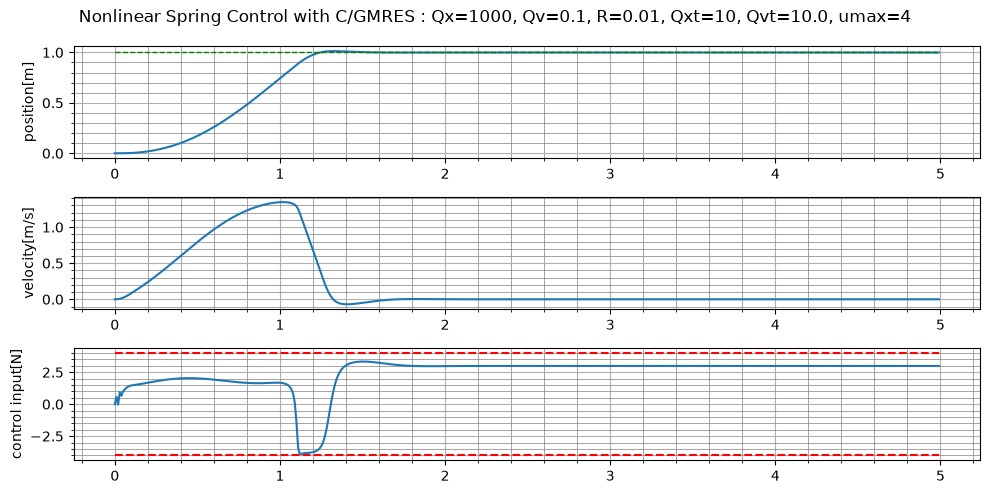

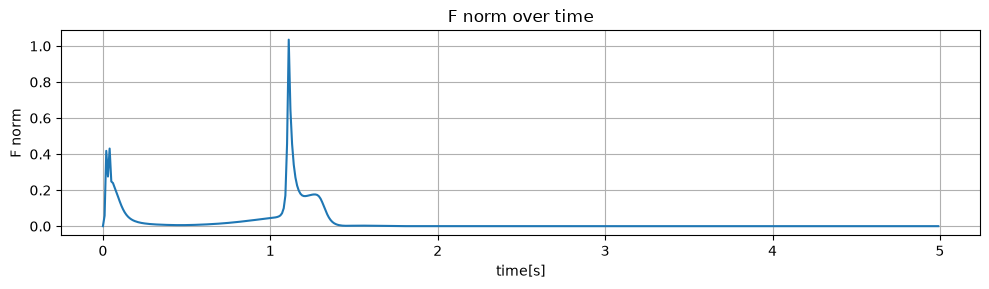

C/GMRES mean time: 1.4364868436673706 [ms]
C/GMRES max time: 10.913434999565652 [ms]
C/GMRES min time: 0.22759399962524185 [ms]


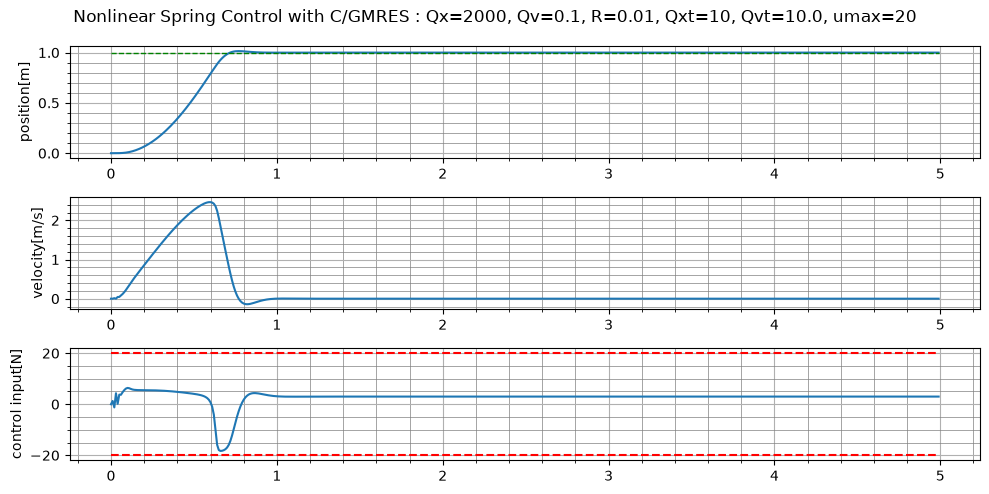

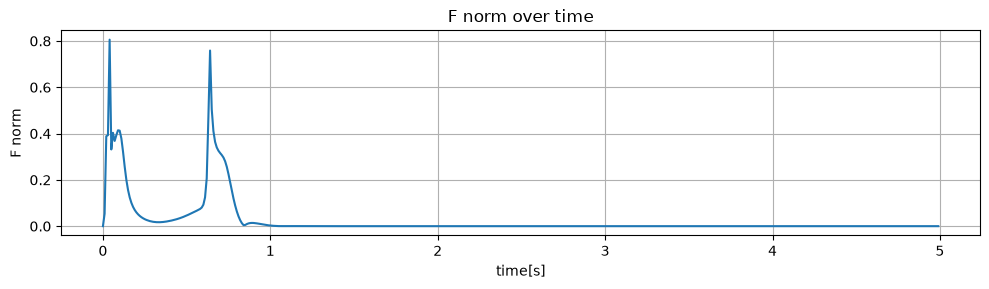

In [20]:
params1 = Parameters()
params1.qxt = 10
params1.qx = 1000
params1.qv = 0.1
params1.r = 0.01
params1.Tf = 2.0
params1.eps = 1e-3
params1.N = 30
params1.u_max = 4
params1.r_d = 0.09
params1.zeta = 50

t1_array, x1_array, u1_array, f1_norm_array, _ = calc_simulation(params1, N=500)
plot_results(t1_array, x1_array, u1_array, params1)
plot_f_norm(t1_array, f1_norm_array)

params1.qx = 2000
params1.u_max = 20

t2_array, x2_array, u2_array, f2_norm_array, _ = calc_simulation(params1, N=500)
plot_results(t2_array, x2_array, u2_array, params1)
plot_f_norm(t2_array, f2_norm_array)


結果は、入力制約を守っていることが分かる。

また、ゆっくりと立ち上がり、目標値到達前に急減速するような動きになっている。意図的にこのような指令は与えていないが、C/GMRESが自動的に計算した値である。

### $\zeta$ が異なる場合の挙動確認

In [29]:
params2 = Parameters()
params2.qxt = 10
params2.qx = 1000
params2.qv = 0.1
params2.r = 0.01
params2.Tf = 2.0
params2.eps = 1e-3
params2.N = 30
params2.u_max = 4
params2.r_d = 0.09
params2.zeta = 50

t1_array, x1_array, u1_array, f1_norm_array, _ = calc_simulation(params2, N=500)

params2.zeta = 20

t2_array, x2_array, u2_array, f2_norm_array, _ = calc_simulation(params2, N=500)

params2.zeta = 0

t3_array, x3_array, u3_array, f3_norm_array, _ = calc_simulation(params2, N=500)


C/GMRES mean time: 1.91184591984964 [ms]
C/GMRES max time: 13.864393000403652 [ms]
C/GMRES min time: 0.36069799989491 [ms]
C/GMRES mean time: 1.9168899458794135 [ms]
C/GMRES max time: 10.723733999839169 [ms]
C/GMRES min time: 0.3585739996196935 [ms]
C/GMRES mean time: 10.749690799588542 [ms]
C/GMRES max time: 19.049427000027208 [ms]
C/GMRES min time: 0.7418049999614595 [ms]


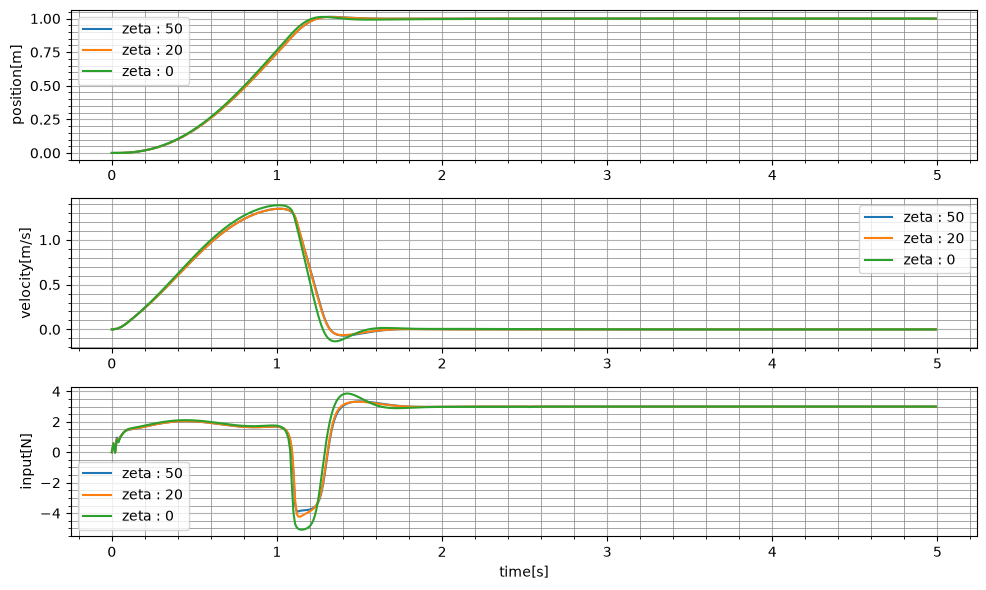

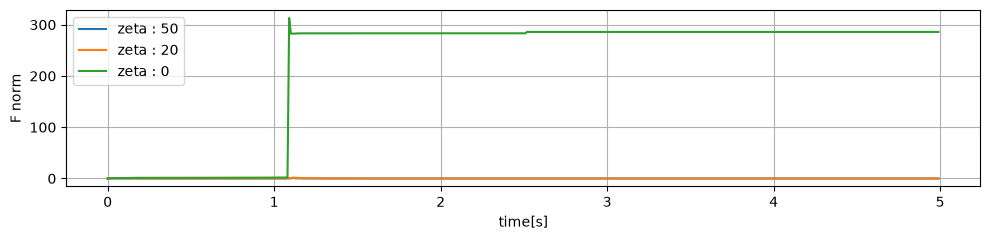

In [38]:
fig, ax = plt.subplots(3,1, figsize=(10,6))

ax[0].plot(t1_array, x1_array[:,0] , label = "zeta : 50")
ax[0].plot(t2_array, x2_array[:,0] , label = "zeta : 20")
ax[0].plot(t3_array, x3_array[:,0] , label = "zeta : 0")
ax[0].set_ylabel("position[m]")
ax[1].plot(t1_array, x1_array[:,1] , label = "zeta : 50")
ax[1].plot(t2_array, x2_array[:,1] , label = "zeta : 20")
ax[1].plot(t3_array, x3_array[:,1] , label = "zeta : 0")
ax[1].set_ylabel("velocity[m/s]")
ax[2].plot(t1_array, u1_array , label = "zeta : 50")
ax[2].plot(t2_array, u2_array , label = "zeta : 20")
ax[2].plot(t3_array, u3_array , label = "zeta : 0")
ax[2].set_ylabel("input[N]")
ax[2].set_xlabel("time[s]")

for i in range(3):
    ax[i].grid()
    ax[i].grid(which='minor', lw=0.5, color='grey')
    ax[i].minorticks_on()
    ax[i].legend()

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(1,1, figsize=(10,2.5))
ax.plot(t1_array, f1_norm_array, label = "zeta : 50")
ax.plot(t2_array, f2_norm_array, label = "zeta : 20")
ax.plot(t3_array, f3_norm_array, label = "zeta : 0")
ax.set_ylabel("F norm")
ax.set_xlabel("time[s]")

ax.grid()
ax.legend()

fig.tight_layout()
plt.show()



今回は$\zeta$が異なると挙動も異なる結果となった。また、C/GMRESの計算が$\zeta=0$ の時は周期が大きくなっている。そして、Fのノルムも 0 を追跡できていないことが分かる。

このように、計算に制約を入れ徐々に複雑になってくると、$\zeta$の影響が出てくるといえる。



## PID制御器 + 制御飽和制約との比較

C/GMRES mean time: 2.0207079198229336 [ms]
C/GMRES max time: 16.546854998523486 [ms]
C/GMRES min time: 0.35232200025347993 [ms]


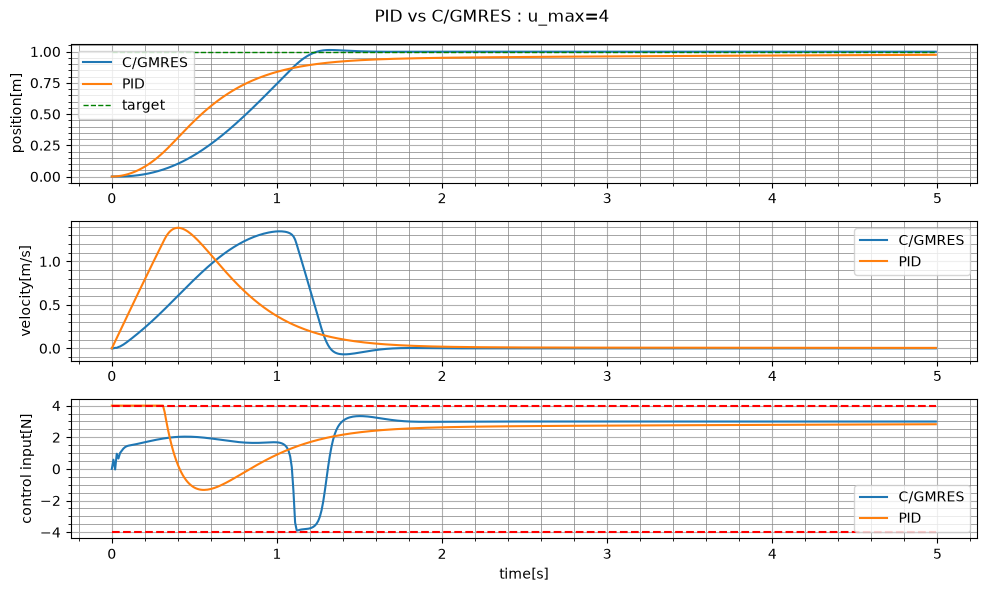

In [39]:
class PIDController:
    """制御入力飽和(±u_max)とアンチワインドアップ付きのPID制御器"""
    def __init__(self, kp: float, ki: float, kd: float, u_max: float, dt: float):
        self.kp = kp
        self.ki = ki
        self.kd = kd
        self.u_max = u_max
        self.dt = dt

        self.integral = 0.0
        self.prev_error = None

    def reset(self):
        self.integral = 0.0
        self.prev_error = None

    def calc_input(self, target: float, x: float) -> float:
        error = target - x

        # 微分項(初回はゼロ)
        if self.prev_error is None:
            d_error = 0.0
        else:
            d_error = (error - self.prev_error) / self.dt
        self.prev_error = error

        # 飽和前の候補入力(積分項は飽和前の値で仮計算)
        u_unclamped = (
            self.kp * error
            + self.ki * (self.integral + error * self.dt)
            + self.kd * d_error
        )

        u = np.clip(u_unclamped, -self.u_max, self.u_max)

        # アンチワインドアップ: 飽和しておらず、または飽和方向と誤差の符号が逆の場合のみ積分を更新
        if u == u_unclamped or (u_unclamped * error < 0):
            self.integral += error * self.dt

        return u


def calc_simulation_pid(params: Parameters, kp: float, ki: float, kd: float, N: int = 500):
    plant = NonlinearSpringPlant(
        params,
        X0=np.array([0.0, 0.0])
    )

    controller = PIDController(kp, ki, kd, params.u_max, params.dt)

    dt = params.dt
    t = 0.0

    X_array = np.zeros((N, 2))
    u_array = np.zeros(N)
    t_array = np.zeros(N)

    for i in range(N):
        t_array[i] = t

        # step 1 plantの現在状態を取得
        X = plant.get_state()
        X_array[i] = X

        # step 2 PIDで制御入力を計算(位置のみをフィードバック)
        u = controller.calc_input(params.x_target, X[0])
        u_array[i] = u

        # step 3
        plant.step(u, dt)

        t += dt

    return (t_array, X_array, u_array)


# C/GMRESと同じプラント・目標値・入力制約でPID制御を実行して比較
params_pid = Parameters()
params_pid.qxt = 10
params_pid.qx = 1000
params_pid.qv = 0.1
params_pid.r = 0.01
params_pid.Tf = 2.0
params_pid.eps = 1e-3
params_pid.N = 30
params_pid.u_max = 4
params_pid.r_d = 0.09
params_pid.zeta = 50

t_gmres, x_gmres, u_gmres, f_norm_gmres, _ = calc_simulation(params_pid, N=500)
t_pid, x_pid, u_pid = calc_simulation_pid(params_pid, kp=20.0, ki=5.0, kd=10.0, N=500)

fig, ax = plt.subplots(3, 1, figsize=(10, 6))
ax[0].plot(t_gmres, x_gmres[:, 0], label="C/GMRES")
ax[0].plot(t_pid, x_pid[:, 0], label="PID")
ax[0].hlines(params_pid.x_target, t_gmres[0], t_gmres[-1], color='g', lw=1.0, linestyle='--', label='target')
ax[0].set_ylabel("position[m]")

ax[1].plot(t_gmres, x_gmres[:, 1], label="C/GMRES")
ax[1].plot(t_pid, x_pid[:, 1], label="PID")
ax[1].set_ylabel("velocity[m/s]")

ax[2].plot(t_gmres, u_gmres, label="C/GMRES")
ax[2].plot(t_pid, u_pid, label="PID")
ax[2].hlines(params_pid.u_max, t_gmres[0], t_gmres[-1], color='r', linestyle='--')
ax[2].hlines(-params_pid.u_max, t_gmres[0], t_gmres[-1], color='r', linestyle='--')
ax[2].set_ylabel("control input[N]")
ax[2].set_xlabel("time[s]")

for i in range(3):
    ax[i].grid()
    ax[i].grid(which="minor", lw=0.5, color='grey')
    ax[i].minorticks_on()
    ax[i].legend()

plt.suptitle(f"PID vs C/GMRES : u_max={params_pid.u_max}")
fig.tight_layout()
plt.show()


今回ダミー変数による制約を実施した。次は$\log$によるバリア関数の検証を行う。